<a href="https://colab.research.google.com/github/vvrgit/ML-Optimization/blob/main/ADADELTA_UDEMY_MB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random
import math as mt

In [ ]:
data=[[0.1,0.2,0.3],[0.2,0.3,0.5],[0.3,0.4,0.7],[0.4,0.5,0.9]]
data=pd.DataFrame(data,columns=['x1','x2','y'])
data

,x1,x2,y
0,0.1,0.2,0.3
1,0.2,0.3,0.5
2,0.3,0.4,0.7
3,0.4,0.5,0.9


In [ ]:
bs=2
ns=data.shape[0]
nb=int(ns/bs)
batches=np.array_split(data,nb)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
epochs=2000
gama=0.9
m1=random.uniform(-1,1)
m2=random.uniform(-1,1)
c=random.uniform(-1,1)
eps=mt.pow(10,-8)
Em1=0
Em2=0
Ec=0
Edm1=0
Edm2=0
Edc=0
dm1=0
dm2=0
dc=0

In [ ]:
for iter in range(1):
  for b in range(nb):
    gm1=0
    gm2=0
    gc=0
    for sample in range(bs):
      x1=batches[b]['x1'].iloc[sample]
      x2=batches[b]['x2'].iloc[sample]
      y=batches[b]['y'].iloc[sample]


      gm1=gm1+(y-m1*x1-m2*x2-c)*x1
      gm2=gm2+(y-m1*x1-m2*x2-c)*x2
      gc=gc+(y-m1*x1-m2*x2-c)


    gm1=(-1/bs)*gm1
    gm2=(-1/bs)*gm2
    gc=(-1/bs)*gc


    Em1=gama*Em1+(1-gama)*mt.pow(gm1,2)
    Em2=gama*Em2+(1-gama)*mt.pow(gm2,2)
    Ec=gama*Ec+(1-gama)*mt.pow(gc,2)

    Edm1=gama*Edm1+(1-gama)*dm1
    Edm2=gama*Edm2+(1-gama)*dm2
    Edc=gama*Edc+(1-gama)*dc

    dm1=-((np.sqrt(Edm1+eps))/(np.sqrt(Em1+eps)))*gm1
    dm2=-((np.sqrt(Edm2+eps))/(np.sqrt(Em2+eps)))*gm2
    dc=-((np.sqrt(Edc+eps))/(np.sqrt(Ec+eps)))*gc

    m1=m1+dm1
    m2=m2+dm2
    c=c+dc
print(m1)
print(m2)
print(c)

0.4450405435877841
-0.40654975870729215
-0.08164840706018925


**Replace N with bs**

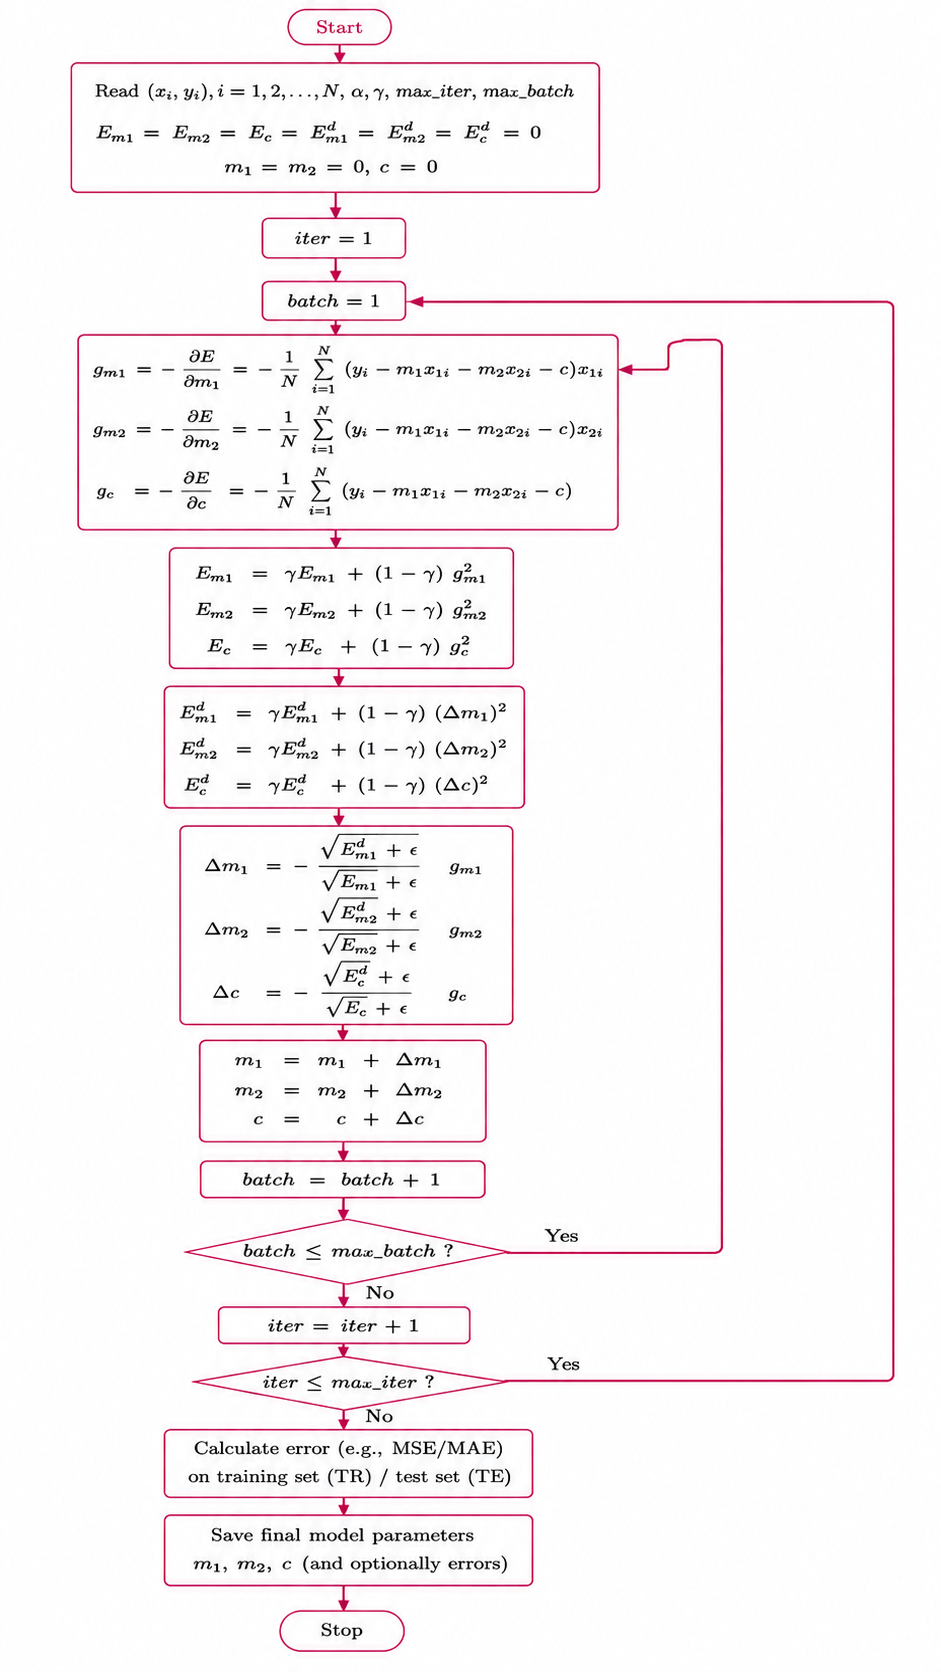